# **Implementación del caso de 10 Qubits.**

In [74]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa as q
from modules import utils

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
N10 = 261980999226229

## **1. Implementación con 8 Qubits**

In [76]:
seed = 51

In [77]:
eightQubit = sl.schnorrCVP(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 128


### **1.1 Algoritmo de Schnorr**

In [78]:
cvpinstance = eightQubit.generate_cvp(10)

B = 
[ 2 0 0 0 0 0 0 0  6931 ]
[ 0 3 0 0 0 0 0 0 10986 ]
[ 0 0 2 0 0 0 0 0 16094 ]
[ 0 0 0 4 0 0 0 0 19459 ]
[ 0 0 0 0 1 0 0 0 23979 ]
[ 0 0 0 0 0 3 0 0 25649 ]
[ 0 0 0 0 0 0 1 0 28332 ]
[ 0 0 0 0 0 0 0 4 29444 ]
t = 
(0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [79]:
cvpResult = eightQubit.babai_algorithm(cvpinstance, delta = 0.99)
print(f'D = \n{cvpResult.D}\n')
print(f'b_op = \n{cvpResult.b_op}\n')
print(f'res_vector = \n{cvpResult.res_vector}\n')
print(f'step_sign = \n{cvpResult.step_sign}\n')
print(f'weights = \n{cvpResult.weight}\n')

D = 
[  2  0 -4 -4  3  0 -2  4  1 ]
[  0 -3  4  0 -2  3 -1  4  5 ]
[  6 -3  0  0 -4  0  2  4 -1 ]
[  4  0 -2  0 -2  6  1 -4 -4 ]
[ -4  0  6  4 -1  3 -3  4 -3 ]
[  2 -6  6  0  2 -3 -3  4 -2 ]
[  2 -6 -4  4  1 -3  0  4  4 ]
[ -8 -3  0  0 -3  3  3  0 -2 ]

b_op = 
[     2      0      2      0      0      3     10      0 331994]

res_vector = 
[ -2   0  -2   0   0  -3 -10   0  -1]

step_sign = 
[ 1 -1 -1 -1  1  1  1 -1]

weights = 
(-8765, 35541, -13511, -8003, -15327, -12503, 6562, -10148)



### **1.2 Algoritmo QAOA**

In [80]:
qubo8 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, eightQubit.n)
print(qubo8.prettyprint())

Hc8, offset8 = q.define_hamiltonian(qubo8)
print(f'Offset = {offset8}')
print(f'Hamiltonian = {Hc8}')

Problem name: quboProblem

Minimize
  66*z_0^2 - 2*z_0*z_1 - 22*z_0*z_2 + 24*z_0*z_3 - 64*z_0*z_4 + 12*z_0*z_5
  + 54*z_0*z_6 + 66*z_0*z_7 + 80*z_1^2 + 52*z_1*z_2 - 46*z_1*z_3 - 78*z_1*z_4
  - 76*z_1*z_5 - 54*z_1*z_6 + 22*z_1*z_7 + 82*z_2^2 + 44*z_2*z_3 + 14*z_2*z_4
  - 68*z_2*z_5 - 76*z_2*z_6 - 38*z_2*z_7 + 93*z_3^2 + 30*z_3*z_4 + 74*z_3*z_5
  + 72*z_3*z_6 + 6*z_3*z_7 + 112*z_4^2 + 96*z_4*z_5 - 44*z_4*z_6 - 82*z_4*z_7
  + 118*z_5^2 + 70*z_5*z_6 + 36*z_5*z_7 + 114*z_6^2 + 36*z_6*z_7 + 104*z_7^2
  - 46*z_0 - 24*z_1 - 62*z_2 - 56*z_3 - 40*z_4 - 50*z_5 - 18*z_6 - 42*z_7 + 118

Subject to
  No constraints

  Binary variables (8)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7

Offset = 348.0
Hamiltonian = SparsePauliOp(['IIIIIIIZ', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZI', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'IIZIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'IIZIIIZI', 'IZIIIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIIZIZII', 'IIZIIZII'

In [81]:
circuit8 = q.construct_circuit(Hc8, reps = 1)
print(circuit8)

     ┌───┐ ┌────────────────┐                                           »
q_0: ┤ H ├─┤ Rz((-54)*γ[0]) ├─■───────────■────────────────■────────────»
     ├───┤ └┬─────────────┬─┘ │ZZ(-γ[0])  │                │            »
q_1: ┤ H ├──┤ Rz(35*γ[0]) ├───■───────────┼────────────────┼────────────»
     ├───┤  ├─────────────┤               │ZZ((-11)*γ[0])  │            »
q_2: ┤ H ├──┤ Rz(27*γ[0]) ├───────────────■────────────────┼────────────»
     ├───┤┌─┴─────────────┴─┐                              │ZZ(12*γ[0]) »
q_3: ┤ H ├┤ Rz((-139)*γ[0]) ├──────────────────────────────■────────────»
     ├───┤└┬───────────────┬┘                                           »
q_4: ┤ H ├─┤ Rz((-8)*γ[0]) ├────────────────────────────────────────────»
     ├───┤┌┴───────────────┴┐                                           »
q_5: ┤ H ├┤ Rz((-140)*γ[0]) ├───────────────────────────────────────────»
     ├───┤├─────────────────┤                                           »
q_6: ┤ H ├┤ Rz((-125)*γ[0]) ├─────────

In [82]:
x0 = np.asarray([0.0]*circuit8.num_parameters)
_, optParameters8 = q.qaoa_algorithm(circuit8, Hc8, x0)

In [83]:
for param in optParameters8.items():
    print(f'{param[0]} = {param[1]}')

β[0] = -0.4799726604811829
γ[0] = 0.008447652215877989


In [84]:
results8 = q.sample_from_parameters(circuit8, optParameters8, shots = 10_000)
print(len(results8))
for bitstring, count in results8.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

209
Bistring: 00000100 -> Counts: 379
Bistring: 00010011 -> Counts: 351
Bistring: 00100110 -> Counts: 317
Bistring: 00000000 -> Counts: 294
Bistring: 00010010 -> Counts: 270
Bistring: 00000010 -> Counts: 269
Bistring: 00000101 -> Counts: 244
Bistring: 01010110 -> Counts: 240
Bistring: 00100100 -> Counts: 230
Bistring: 00010111 -> Counts: 216
Bistring: 10010010 -> Counts: 216
Bistring: 00100010 -> Counts: 215
Bistring: 00001010 -> Counts: 213
Bistring: 10000100 -> Counts: 209
Bistring: 01010111 -> Counts: 191
Bistring: 00000110 -> Counts: 182
Bistring: 00100111 -> Counts: 178
Bistring: 10010100 -> Counts: 176
Bistring: 10010110 -> Counts: 175
Bistring: 00010101 -> Counts: 173
Bistring: 01000100 -> Counts: 166
Bistring: 00010110 -> Counts: 161
Bistring: 01000110 -> Counts: 152
Bistring: 11010110 -> Counts: 151
Bistring: 10010101 -> Counts: 149
Bistring: 00100101 -> Counts: 140
Bistring: 00000001 -> Counts: 137
Bistring: 01010010 -> Counts: 137
Bistring: 00000011 -> Counts: 132
Bistring: 

### **1.3 Obtención de SR-Pairs**

In [85]:
nD8 = sl.integer_to_matrix(cvpResult.D)
vnew8 = sl.bitstring2latticeVectors(nD8, results8.keys(), cvpResult.step_sign, cvpResult.b_op)
for vect8 in vnew8:
    print(vect8)

[    -4      3      2      0      4      3      8     -4 331995]
[     0      3      0      0      4      3      6      4 331987]
[    -2      0      4      0      8     -3      6     -4 331988]
[     2      0      2      0      0      3     10      0 331994]
[    -2      3      4      4      1      3      8      0 331986]
[     2      3     -2      0      2      0     11     -4 331989]
[    -2      3     -2     -4      7      3      6      0 331996]
[    -6      0      0      8      6      0      6      0 331991]
[    -2     -3      8      0      6      0      5      0 331993]
[    -6      6      0      0      8      3      4      0 331988]
[     6      6      4      4      4      0      5      0 331988]
[     4     -3      4      0      4     -3      8      0 331987]
[    -2      3      0      0      4     -6     10      0 331993]
[     4      6      2      0      7      0      5     -4 331997]
[    -4      0     -4      4      9      0      4      4 331992]
[    -4      6     -2    

In [86]:
distances8 = utils.get_distances(vnew8, cvpinstance.t)
for dist in distances8:
    print(dist)

11.74734012447073
11.045361017187261
13.038404810405298
10.862780491200215
12.96148139681572
13.19090595827292
11.661903789690601
13.2664991614216
11.74734012447073
13.638181696985855
13.038404810405298
12.884098726725126
12.84523257866513
12.727922061357855
12.727922061357855
15.684387141358123
13.341664064126334
12.884098726725126
14.7648230602334
12.569805089976535
12.569805089976535
15.937377450509228
14.560219778561036
13.2664991614216
12.884098726725126
12.165525060596439
11.74734012447073
12.884098726725126
13.856406460551018
13.74772708486752
12.449899597988733
12.083045973594572
12.922847983320086
15.556349186104045
14.7648230602334
14.035668847618199
14.696938456699069
14.966629547095765
13.038404810405298
13.341664064126334
13.784048752090222
14.352700094407323
16.76305461424021
14.142135623730951
14.798648586948742
14.0
13.784048752090222
14.071247279470288
14.38749456993816
13.19090595827292
14.696938456699069
13.711309200802088
13.416407864998739
15.874507866387544
16.552

In [87]:
nB8 = sl.integer_to_matrix(cvpinstance.B)
uv_pairs8 = sl.vectors2uv_pairs(nB8, vnew8, eightQubit.n)
print(uv_pairs8)

[[19915752615267795 76]
 [261868027467189 1]
 [129352557022507225 494]
 [262079207058370 1]
 [523704989883075 2]
 [24881396719341558 95]
 [18344544450464661 70]
 [2095297617885241 8]
 [1572102054235625 6]
 [2094705767700117 8]
 [261930391846200 1]
 [10213206469368100 39]
 [88548500089421427 338]
 [4980419307818460 19]
 [26192773830301463 100]
 [1890770913674116353 7220]
 [23829516041101331 91]
 [262070340406875 1]
 [4976110986617925 19]
 [2096063541654225 8]
 [7864168981413437 30]
 [79594097822264025 304]
 [16176595594767439909 61750]
 [3405871519729602 13]
 [262085885854650 1]
 [5502683577794425 21]
 [9173316356123348 35]
 [785826051486091 3]
 [229184353172620164 875]
 [27239768591429625 104]
 [6815838201665075 26]
 [262037768531825 1]
 [13620692197897455 52]
 [8708014138755186387 33250]
 [1047223518265375 4]
 [44277791974589250 169]
 [261916113620898 1]
 [4191878430114375 16]
 [262100173335000 1]
 [262159937104450 1]
 [5764488970638125 22]
 [398405875629322253 1521]
 [134578400326216

In [88]:
sr_pairs8 = sl.uv_pairs2sr_pairs(uv_pairs8, eightQubit)
print(sr_pairs8)

[]


In [89]:
probs8 = utils.get_probs(results8.values(), shots = 10_000)

In [90]:
utils.prettyprint(vnew8, distances8, probs8, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [     2      0      2      0      0      3     10      0 331994]

El vector residual 
t - b_op = [ -2   0  -2   0   0  -3 -10   0  -1]

La distancia |t - b_op| = 10.863

0: Prob = 0.03790
	vnew = [    -4      3      2      0      4      3      8     -4 331995] con distancia: 11.747
1: Prob = 0.03510
	vnew = [     0      3      0      0      4      3      6      4 331987] con distancia: 11.045
2: Prob = 0.03170
	vnew = [    -2      0      4      0      8     -3      6     -4 331988] con distancia: 13.038
3: Prob = 0.02940
	vnew = [     2      0      2      0      0      3     10      0 331994] con distancia: 10.863
4: Prob = 0.02700
	vnew = [    -2      3      4      4      1      3      8      0 331986] con distancia: 12.961
5: Prob = 0.02690
	vnew = [     2      3     -2      0      2      0     11     -4 331989] con distancia: 13.191
6: Prob = 0.02440
	vnew = [    -2      3     -2     -4      7      3      6      0 331996] con distanci

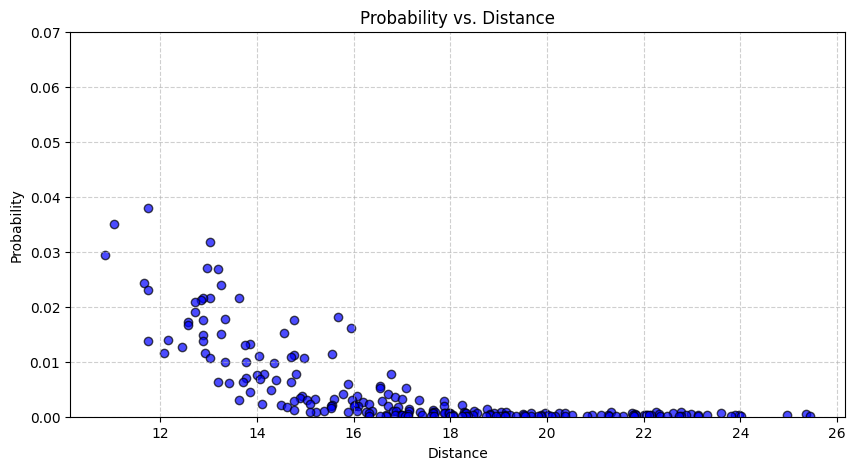

In [91]:
plt.figure(figsize=(10, 5))

# Creating the scatter plot
plt.scatter(distances8, probs8, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.07) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("figures/10QubitCase_8Qubits_ProbsDistances.png", dpi=150, bbox_inches="tight")
plt.show()

## **2. Implementación con 10 Qubits**

In [92]:
seed = 42

In [93]:
tenQubit = sl.schnorrCVP(N10, 4, 1, seed, verbose = False)

### **2.1 Algoritmo de Schnorr**

In [94]:
tenQubit.set_n(10)
tenQubit.set_smoothbound(200)

diag_yan = [3, 2, 3, 1, 1, 3, 1, 1, 2, 2]

print(f'La dimension del retículo que vamos a tratar es n = {tenQubit.get_n()}')
print(f'La cota smooth que vamos a tomar es Smooth Bound = {tenQubit.get_smoothbound()}')

La dimension del retículo que vamos a tratar es n = 10
La cota smooth que vamos a tomar es Smooth Bound = 200


In [95]:
cvpinstance = tenQubit.generate_cvp(10, diagonal = diag_yan)

B = 
[ 3 0 0 0 0 0 0 0 0 0  6931 ]
[ 0 2 0 0 0 0 0 0 0 0 10986 ]
[ 0 0 3 0 0 0 0 0 0 0 16094 ]
[ 0 0 0 1 0 0 0 0 0 0 19459 ]
[ 0 0 0 0 1 0 0 0 0 0 23979 ]
[ 0 0 0 0 0 3 0 0 0 0 25649 ]
[ 0 0 0 0 0 0 1 0 0 0 28332 ]
[ 0 0 0 0 0 0 0 1 0 0 29444 ]
[ 0 0 0 0 0 0 0 0 2 0 31355 ]
[ 0 0 0 0 0 0 0 0 0 2 33673 ]
t = 
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [96]:
cvpResult = tenQubit.babai_algorithm(cvpinstance, delta = 0.75)
print(f'D10 = \n{cvpResult.D}\n')
print(f'b_op10 = \n{cvpResult.b_op}\n')
print(f'res_vector10 = \n{cvpResult.res_vector}\n')
print(f'step_sign10 = \n{cvpResult.step_sign}\n')
print(f'weights10 = \n{cvpResult.weight}\n')

D10 = 
[  0  0 -3  1  2  0 -3  0  0  2  0 ]
[  0  0  0  2  0  0  3 -2 -2 -2 -2 ]
[  3  2  0  1  2 -3 -1  0 -2  0 -2 ]
[  0  0  0  4 -2 -3  0  1  0 -2  0 ]
[  0  4  0 -4  0  0  1  2 -2  0  1 ]
[  0 -4  0 -2  0  0  2 -1  0  2  3 ]
[  3  0 -3 -2  1  0  1  1  0 -2  1 ]
[  0  4  0  0 -1  0  2 -3  0  2 -2 ]
[ -3 -2  0 -1  0 -3 -2  3  2  0 -2 ]
[ -3  4  0  0  4 -3 -1 -3  2  0 -1 ]

b_op10 = 
[     3      4      0      1      2      3      2      3      2      2
 331993]

res_vector10 = 
[-3 -4  0 -1 -2 -3 -2 -3 -2 -2  0]

step_sign10 = 
[-1  1 -1  1 -1  1 -1 -1  1  1]

weights10 = 
(5953, -29824, -18221, 42395, 23869, 29891, -5953, -29225, -45689, 21514)



### **2.2 Algoritmo QAOA**

In [97]:
qubo10 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, tenQubit.n)
print(qubo10.prettyprint())


Hc10, offset10 = q.define_hamiltonian(qubo10)
print(f'Offset = {offset10}')
print(f'Hamiltonian = \n{Hc10}')

Problem name: quboProblem

Minimize
  27*z_0^2 + 22*z_0*z_1 + 16*z_0*z_2 + 8*z_0*z_3 - 14*z_0*z_4 + 8*z_0*z_5
  + 4*z_0*z_6 - 8*z_0*z_7 - 10*z_0*z_8 - 22*z_0*z_9 + 29*z_1^2 - 14*z_1*z_2
  + 20*z_1*z_3 + 14*z_1*z_4 - 12*z_1*z_5 + 2*z_1*z_6 - 24*z_1*z_7 - 28*z_1*z_8
  + 2*z_1*z_9 + 36*z_2^2 - 18*z_2*z_3 + 10*z_2*z_4 + 36*z_2*z_5 + 12*z_2*z_6
  + 16*z_2*z_7 + 6*z_2*z_8 - 30*z_2*z_9 + 34*z_3^2 + 28*z_3*z_4 - 26*z_3*z_5
  + 10*z_3*z_6 + 10*z_3*z_7 + 16*z_3*z_8 - 4*z_3*z_9 + 42*z_4^2 + 10*z_4*z_5
  + 24*z_4*z_6 + 20*z_4*z_7 + 12*z_4*z_8 - 8*z_4*z_9 + 38*z_5^2 - 8*z_5*z_6
  + 22*z_5*z_7 - 6*z_5*z_8 - 36*z_5*z_9 + 30*z_6^2 - 16*z_6*z_7 + 16*z_6*z_8
  + 20*z_6*z_9 + 38*z_7^2 + 34*z_7*z_8 - 42*z_7*z_9 + 44*z_8^2 + 18*z_8*z_9
  + 65*z_9^2 - 6*z_0 - 12*z_1 - 14*z_2 - 20*z_3 - 32*z_4 - 26*z_5 - 20*z_6
  - 26*z_7 - 36*z_8 - 2*z_9 + 60

Subject to
  No constraints

  Binary variables (10)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7 z_8 z_9

Offset = 177.0
Hamiltonian = 
SparsePauliOp(['IIIIIIIZII', 'IIIZIIII

In [98]:
circuit10 = q.construct_circuit(Hc10, reps= 1)
print(circuit10)

     ┌───┐┌────────────────┐                                        »
q_0: ┤ H ├┤ Rz((-23)*γ[0]) ├─■─────────────■────────────■───────────»
     ├───┤├───────────────┬┘ │ZZ(11*γ[0])  │            │           »
q_1: ┤ H ├┤ Rz((-8)*γ[0]) ├──■─────────────┼────────────┼───────────»
     ├───┤├───────────────┴┐               │ZZ(8*γ[0])  │           »
q_2: ┤ H ├┤ Rz((-39)*γ[0]) ├───────────────■────────────┼───────────»
     ├───┤├────────────────┤                            │ZZ(4*γ[0]) »
q_3: ┤ H ├┤ Rz((-36)*γ[0]) ├────────────────────────────■───────────»
     ├───┤├────────────────┤                                        »
q_4: ┤ H ├┤ Rz((-58)*γ[0]) ├────────────────────────────────────────»
     ├───┤├───────────────┬┘                                        »
q_5: ┤ H ├┤ Rz((-6)*γ[0]) ├─────────────────────────────────────────»
     ├───┤├───────────────┴┐                                        »
q_6: ┤ H ├┤ Rz((-42)*γ[0]) ├────────────────────────────────────────»
     ├───┤├─────────

In [99]:
x0 = np.asarray([0.0]*circuit10.num_parameters)
monitor, optParameters10 = q.qaoa_algorithm(circuit10, Hc10, x0)

In [100]:
print(f'Iteraciones = {monitor.iteration}')
print(f'Evolucion: ')
for angles, value in zip(monitor.parameters, monitor.evaluation):
    print(f'{angles}: {value}')

Iteraciones = 50
Evolucion: 
[-0.0005    0.000375]: -0.003483558641774821
[-0.00075    0.0009375]: -0.013056034474713223
[-0.001875    0.00146875]: -0.05108518625907177
[-0.0029375   0.00285937]: -0.15509494935453105
[-0.00571875  0.00461719]: -0.4826190152559398
[-0.00923438  0.00827734]: -1.347287287690014
[-0.01655469  0.01362305]: -3.6288633437585616
[-0.02724609  0.02361621]: -7.713791714019326
[-0.04723242  0.0393042 ]: -9.563533881469361
[-0.04723242  0.0393042 ]: -9.563533881469361
[-0.03732654  0.03172885]: -9.800256968712699
[-0.03697742  0.03065427]: -9.920882961681345
[-0.0421922   0.03524788]: -10.044179064437573
[-0.04410135  0.03539552]: -10.43791200064051
[-0.04410135  0.03539552]: -10.43791200064051
[-0.04186077  0.03207949]: -10.880948620053472
[-0.04881898  0.03523654]: -11.5874895056719
[-0.04781693  0.03018301]: -12.8642889920399
[-0.06123233  0.03397036]: -15.007922971748101
[-0.06593592  0.02575697]: -18.340545063504
[-0.09511853  0.02922496]: -25.240171369643253

In [101]:
for param in optParameters10.items():
    print(f'{param[0]} = {param[1]}')

β[0] = -0.4906189556221089
γ[0] = 0.024643835357168208


In [102]:
results10 = q.sample_from_parameters(circuit10, optParameters10, shots = 10_000)
print(len(results10))
for bitstring, count in results10.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

617
Bistring: 0000000000 -> Counts: 298
Bistring: 0100100010 -> Counts: 235
Bistring: 0100000010 -> Counts: 205
Bistring: 0000101000 -> Counts: 177
Bistring: 1010100010 -> Counts: 177
Bistring: 0000100000 -> Counts: 172
Bistring: 1010000110 -> Counts: 152
Bistring: 0010000010 -> Counts: 147
Bistring: 0000000010 -> Counts: 141
Bistring: 1010000001 -> Counts: 136
Bistring: 0100000110 -> Counts: 136
Bistring: 0000010000 -> Counts: 128
Bistring: 0000000100 -> Counts: 109
Bistring: 0001000000 -> Counts: 107
Bistring: 0011000000 -> Counts: 106
Bistring: 0011000010 -> Counts: 105
Bistring: 0000000001 -> Counts: 104
Bistring: 0010000000 -> Counts: 103
Bistring: 0000100010 -> Counts: 102
Bistring: 0000001000 -> Counts: 97
Bistring: 1000101100 -> Counts: 97
Bistring: 1010100001 -> Counts: 96
Bistring: 0100000001 -> Counts: 95
Bistring: 0000010001 -> Counts: 93
Bistring: 0000000110 -> Counts: 90
Bistring: 1000101000 -> Counts: 84
Bistring: 1010000010 -> Counts: 84
Bistring: 0100100000 -> Counts: 

### **2.3 Obtención de SR-Pairs**

In [103]:
nD10 = sl.integer_to_matrix(cvpResult.D)
vnew10 = sl.bitstring2latticeVectors(nD10, results10.keys(), cvpResult.step_sign, cvpResult.b_op)
for vect10 in vnew10:
    print(vect10)

[     3      4      0      1      2      3      2      3      2      2
 331993]
[     0     -2      0      0      2      0      5      3      2      2
 331992]
[     0      2      0      2      2      0      3      4      2      0
 331989]
[     3      0      0      3      0      0      4      3      2      2
 331996]
[     0      0      0      1      7      0      4      0      2      0
 331995]
[     3      0      0     -1      2      3      4      2      2      4
 331996]
[    -3      2      0      2      5      3      3      1      4     -2
 331994]
[     3      0      0      3      3      3      3      4      0     -2
 331993]
[     3      4      0      3      2      3      5      1      0      0
 331991]
[     0      4      3      0      5      0      2      3      4     -2
 331994]
[    -3      0      0      1      0      3      4      4      4      0
 331991]
[     3      0      0      5      2      3      1      1      4      2
 331992]
[     0      2      0      0      0     

In [104]:
distances10 = utils.get_distances(vnew10, cvpinstance.t)

In [105]:
nB10 = sl.integer_to_matrix(cvpinstance.B)
uv_pairs10 = sl.vectors2uv_pairs(nB10, vnew10, tenQubit.n)
for pair10 in uv_pairs10:
    print(pair10)

[262049748526566 1]
[785989264048241 3]
[261933899831373 1]
[262123789565918 1]
[262041669463651 1]
[1834786083877318 7]
[15197779877823543 58]
[7599879238585634 29]
[261995333265666 1]
[7599591655592805 29]
[523970882661499 2]
[262002304109546 1]
[262101312821829 1]
[262012871275155 1]
[4455399847833935 17]
[262027921960805 1]
[262071085476330 1]
[262119231019646 1]
[262057869447374 1]
[262061237653362 1]
[524179336210761 2]
[12843754318516495 49]
[1834067439956055 7]
[262023637196230 1]
[262046886853479 1]
[3406495379313411 13]
[7597394977286961 29]
[38521473014936659 147]
[261988302332823 1]
[243966644293976505 931]
[1834672660438607 7]
[7602076635180170 29]
[7599827166912145 29]
[262075411643045 1]
[220342393880819595 841]
[31715649309334263 121]
[269672266917047315 1029]
[4454570333762703 17]
[34849540192451193 133]
[98822605541643445 377]
[98794040655060289 377]
[2882955920844965 11]
[9956182147268665 38]
[3406772747336805 13]
[7598215740531955 29]
[262103683594025 1]
[1797061490

In [106]:
sr_pairs10 = sl.uv_pairs2sr_pairs(uv_pairs10, tenQubit)
print(sr_pairs10)

[((785989264048241, 3), 46266369554)]


In [107]:
probs10 = utils.get_probs(results10.values(), shots = 10_000)

In [108]:
utils.prettyprint(vnew10, distances10, probs10, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [     3      4      0      1      2      3      2      3      2      2
 331993]

El vector residual 
t - b_op = [-3 -4  0 -1 -2 -3 -2 -3 -2 -2  0]

La distancia |t - b_op| = 7.746

0: Prob = 0.02980
	vnew = [     3      4      0      1      2      3      2      3      2      2
 331993] con distancia: 7.746
1: Prob = 0.02350
	vnew = [     0     -2      0      0      2      0      5      3      2      2
 331992] con distancia: 7.141
2: Prob = 0.02050
	vnew = [     0      2      0      2      2      0      3      4      2      0
 331989] con distancia: 7.550
3: Prob = 0.01770
	vnew = [     3      0      0      3      0      0      4      3      2      2
 331996] con distancia: 7.746
4: Prob = 0.01770
	vnew = [     0      0      0      1      7      0      4      0      2      0
 331995] con distancia: 8.602
5: Prob = 0.01720
	vnew = [     3      0      0     -1      2      3      4      2      2      4
 331996] con distancia: 8.485
6: Prob 

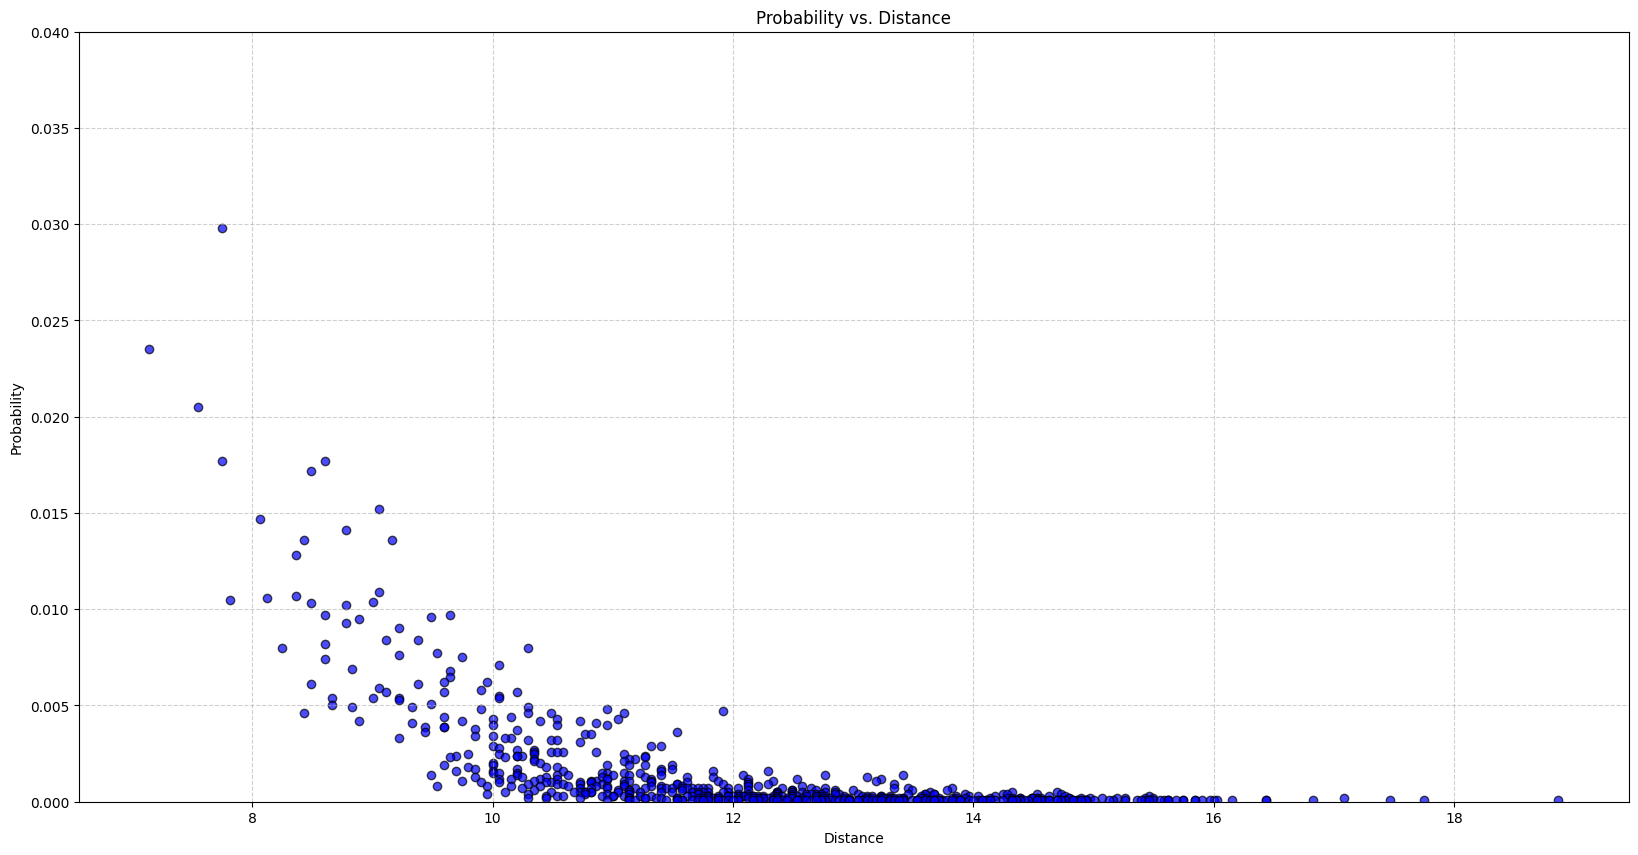

In [109]:
plt.figure(figsize=(20, 10))

# Creating the scatter plot
plt.scatter(distances10, probs10, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.04) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("figures/10QubitCase_10Qubits_ProbsDistances.png", dpi=150, bbox_inches="tight")
plt.show()